# Modelamiento del sistema de discipación para dispositivos electrónicos

**Asignatura:** Máquinas Térmicas  
**Integrantes:**  
- John Esteban Davila
- Juan David Saavedra Silva


El correcto funcionamiento de los vehículos aéreos no tripulados (UAV) en entornos de alta temperatura exige un riguroso proceso de tropicalización estructural y electrónica. Uno de los mayores desafíos bajo estas condiciones atmosféricas es garantizar que la electrónica, particularmente la placa madre, opere dentro de sus márgenes térmicos de seguridad. La incapacidad de evacuar eficientemente el calor acumulado no solo compromete el rendimiento energético del dron, sino que evita la degradación de los componentes y el riesgo de fallos críticos en vuelo.

Para mitigar este riesgo, la presente sección se enfoca en la evaluación, modelado y comparación de diferentes arquitecturas de diseño para el sistema de disipación. El objetivo fundamental es identificar y validar la configuración geométrica que permita extraer la energía térmica de la manera más eficiente posible hacia el ambiente.

Para iniciar es necesario saber cual es la resistencia de la primera barrera de transferencia de calor. Mediante la aplicación de la Ley de Fourier para la conducción térmica, se modela el flujo de calor que transita desde la superficie de la placa madre (Placa 1) a través de la pasta termica hasta alcanzar la base metálica del disipador (Placa 2). Determinar con precisión la temperatura resultante en esta placa superior es un paso importante, ya que dicta las condiciones de contorno iniciales para evaluar el  rechazo de calor por convección de la placa y, en última instancia, dictamina la viabilidad de cada diseño propuesto.

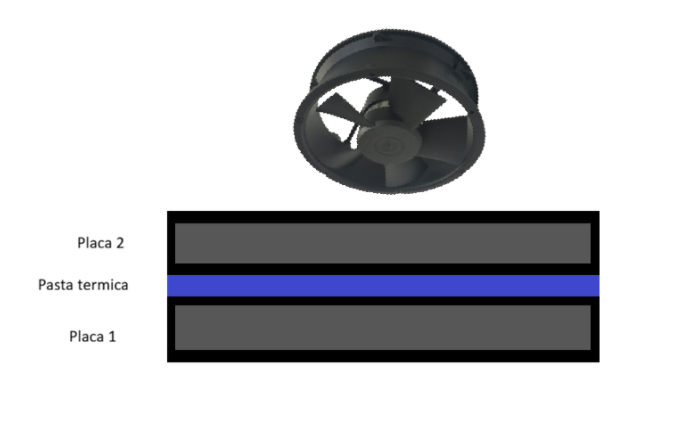



Para establecer el planteamiento de las ecuaciones de transferencia de calor se debe concer como se transmite el calor en cada uno de los puntos del sistema.

# Placa 1

En este caso, la placa 1 corresponde al elemento electrónico que se desea proteger, por lo que se requiere que su temperatura no supere umbrales de peligro. Se parte de la suposición de que el sistema está aislado en este punto y únicamente se transfiere calor por conducción hacia la siguiente placa.

# Pasta térmica

Es la primera parte clave del sistema de disipación de calor, es la encargada de transferir de forma eficiente el calor desde la placa 1 hasta la placa 2, siendo la placa 2 la superficie de un disipador activo de calor. En teoría, la resistencia térmica del sistema debe ser inversamente proporcional a la conductividad térmica de la pasta térmica

# Placa 2 (Disipador)

La placa dos corresponde a la superficie inferior de un disipador, la función de esta placa es concentrar el calor transferido desde el componente electrónico con el fin de mantenerlo en temperaturas seguras. Este componente resibe el aire expulsado por el ventilador, transifiriendo el calor por convección hasta el ambiente.

# Ventilador

El ventilador es la parte actia del sistema de disipación planteado, en este caso, se buscarán diferentes configuraciones para este con el fin de mantener el calor disipado dentro de los rangos seguros de operación del sistema.





# *Resistencia térmica de los materiales (Estado estacionario)*

Si bien el análisis debe ser realizado en un estado transitorio, el valor de las constantes requeridas para el análisis no cambia, por lo que es posible obtenerlo en un análisis en estadio estacionario.

Una primera ecuación clave a tener en cuenta es la resistencia térmica del sistema, esta es totalmente dependiente de cada parte individual del sistema, la formula general en este caso es:

$$R_{\text{cond}} = \frac{L}{k \cdot A}$$

Donde:

$L$: Longitud del componente

$k$: Conductividad térmica del componente ($W/mK$)

$A$: Área transversal por la que se transfiere el calor

En nuestro sistema simplificado, cada una de las placas y la pasta térmica cuentan con una resistencia térmica independiente. Siendo la resistencia térmica de la pasta termica la de mayor incidencia en el sistema, debido a que la Placa 1 es la que genera el calor que debe ser disipado, se asume que no hay un gradiente de temperatura en este punto. Por esta razón, la resistencia térmica total del sistema se expresa de la siguiente manera:

$$R_{\text{total}} = R_{\text{Pasta}} + R_{\text{Placa 2}} + R_{\text{conv}}$$

Donde $R_{\text{conv}}$ corresponde a la resistencia convectiva del sistema, esta variable es de interés para el estudio de la incidencia del ventilador en el sistema.

Las resistencia de cada uno de los componentes se expresan así:

$$R_{\text{pasta}} = \frac{L_{\text{pasta}}}{k_{\text{pasta}} \cdot A}$$

$$R_{\text{placa2}} = \frac{L_{2}}{k_{2} \cdot A}$$

$$R_{\text{conv}} = \frac{1}{h \cdot A}$$

Donde $h$ es el coeficiente de convección entre la Placa 2 y el aire emitido por el ventilador y los valores de las longitudes, conductividades térmicas y áreas son conocidos en todos los casos.









In [ ]:
# Calculo de resistencias térmicas

import numpy as np

# Geometria de las placas (m)

ancho_placa = 0.06
largo_placa = 0.06

# Áreas de transferencia de calor (en m²)
A_pasta  = ancho_placa * largo_placa
A_placa2 = ancho_placa * largo_placa

# Espesores (L) de cada capa en metros
L_pasta  = 0.0005
L_placa2 = 0.005

# Conductividades de materiales
k_placa2 = 205.0      # Conductividad del Aluminio (Placa de disipación)

ks_pastas = [1.81, 3.86, 7.46, 14.78]

# Etiquetas
nombres_pastas = ["Pasta 1", "Pasta 2", "Pasta 3", "Pasta 4"]

# Calculo de resistencias termicas

# Resistencia por conducción de la Placa 2 (Disipador de Aluminio)
R_placa2 = L_placa2 / (k_placa2 * A_placa2)

# Cálculo de las 4 resistencias de las pastas térmicas usando comprensión de listas
R_pastas_calculadas = [L_pasta / (k * A_pasta) for k in ks_pastas]

# Datos obtenios
print("="*65)
print("             VARIABLES GEOMÉTRICAS Y DE CONDUCCIÓN              ")
print("="*65)
print(f"Área de contacto térmico calculada : {A_pasta:.4f} m² ({A_pasta*10000:.1f} cm²)")
print(f"Resistencia de la Placa 2 (Aluminio): {R_placa2:.6f} °C/W")
print("-"*65)
print("Resistencias térmicas individuales calculadas para cada pasta:")

for i in range(4):
    print(f" * {nombres_pastas[i]} (k = {ks_pastas[i]} W/m·K): R_pasta = {R_pastas_calculadas[i]:.6f} °C/W")
print("="*65)

             VARIABLES GEOMÉTRICAS Y DE CONDUCCIÓN              
Área de contacto térmico calculada : 0.0036 m² (36.0 cm²)
Resistencia de la Placa 2 (Aluminio): 0.006775 °C/W
-----------------------------------------------------------------
Resistencias térmicas individuales calculadas para cada pasta:
 * Pasta 1 (k = 1.81 W/m·K): R_pasta = 0.076734 °C/W
 * Pasta 2 (k = 3.86 W/m·K): R_pasta = 0.035982 °C/W
 * Pasta 3 (k = 7.46 W/m·K): R_pasta = 0.018618 °C/W
 * Pasta 4 (k = 14.78 W/m·K): R_pasta = 0.009397 °C/W


Sabiendo que la resistencia térmica es el parámetro que nos indica qué tanta resistencia hace el material a la conducción de temperatura, se entiende que una reducción de este valor implica que la temperatura de la placa 2 aumentará de forma más rápida, acercandose cada vez más al valor de la temperatura de la placa original. Ahora bien, esta parte del análisis se está realizando para un estado estacionario, donde la temperatura se mantiene constante en cierto punto del análisis. Para poder llevar el problema a una aproximación real debe realizarse el análisis tridimensional en estado estacionario. Donde las ecuaciones requeridas corresponden a la Ley de Fourier adaptada al caso de flujo transitorio.

# ***Modelado del sistema***

El sistema de disipación para placas electrónicas debe ser modelado componente por componente, con el fin de entender el comportamiento de cada uno de estos por separado en el estado transitorio.

# **Placa electrónica**

Para modelar este tipo de sistemas es necesario conocer el calor específico y la densidad de los materiales, variables que definen la cantidad de energía que se debe absorber para aumentar la temperatura. En este caso de estudio se asumirá que la placa electrónica está cubierta por una superficie metálica de aluminio.

La ecuación diferencial que rige el calentamiento de una única placa sin tener en cuenta la incidencia del aire (Transferencia por conveccción) es la siguiente:

$$\rho \cdot V \cdot C_p \cdot \frac{dT}{dt} = P_{e}$$

Donde $\rho$ es la densidad del material, $V$ el volumen de la placa y $C_p$ el calor específico. En este caso se asume que la placa es delgada y que la transferencia realizada mantiene la placa completa a la misma temperatura.

Si se desea tener en cuenta la transferencia por convección, pensando en que el sistema real no está aislado, se debe agregar el factor de conducción por convección, el cuál es dependiente de la temperatura ambiente y el área transversal del paso de la temperatura:

$$\rho \cdot V \cdot C_p \cdot \frac{dT}{dt} = P_{e} - h \cdot A_s \cdot (T - T_{\infty})$$

El código planteado para este bloque muestra una aproximación del aumento de la temperatura en la placa madre, con un coeficiente convectivo común para convección natural.




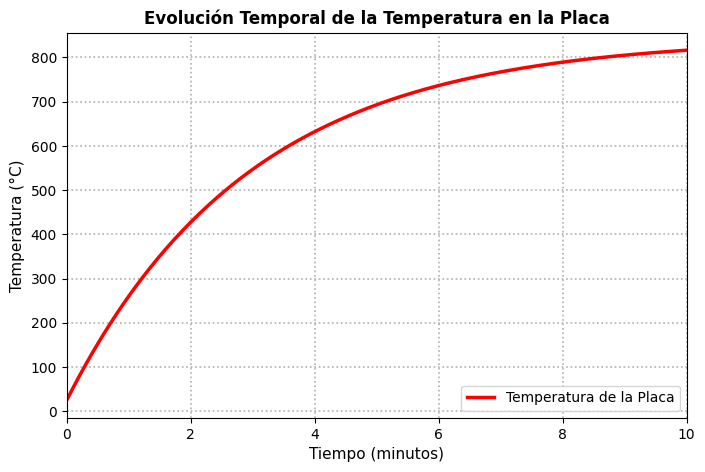

       RESULTADOS DE LA SIMULACIÓN TÉRMICA          
Temperatura inicial: 25.00 °C
Temperatura final (a los 10 min): 816.45 °C
Potencia aplicada: 59.00 W


In [ ]:
# Modelado placa electrónica (Estado transitorio)

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parámetros
alto = 0.06          # 6 cm en metros
ancho = 0.06         # 6 cm en metros
espesor = 0.0016     # Espesor (1.6 mm) en metros
Area_s = 2 * (alto * ancho)  # Área superficial (ambas caras de la placa) [m²]
Volumen = alto * ancho * espesor  # Volumen de la placa [m³]

# Propiedades del material
rho = 1850           # Densidad del [kg/m³]
Cp = 1200            # Calor específico[J/kg·K]

# Condiciones de operación
P_e = 59             # Potencia disipada constante [W]
h = 10               # Coeficiente de convección natural estimado [W/m²·K]
T_amb = 25           # Temperatura ambiente [°C]

# Tiempo de simulación
t_final = 10 * 60    # 10 minutos convertidos a segundos (600 s)
tspan = (0, t_final) # Intervalo de tiempo para el solver (en Python se usa una tupla)

# Condición inicial
T0 = [25]            # La placa inicia a temperatura ambiente

# Resolución ODE

def ode_termica(t, T):
    return (P_e - h * Area_s * (T - T_amb)) / (rho * Volumen * Cp)

t_eval = np.linspace(0, t_final, 300)
solución = solve_ivp(ode_termica, tspan, T0, method='RK45', t_eval=t_eval)

# Tiempos y temperaturas
t = solución.t
T = solución.y[0]

# Grafica de resultados
plt.figure(figsize=(8, 5), facecolor='white')
plt.plot(t / 60, T, 'r-', linewidth=2.5, label='Temperatura de la Placa') # Tiempo en minutos

plt.title('Evolución Temporal de la Temperatura en la Placa', fontsize=12, fontweight='bold')
plt.xlabel('Tiempo (minutos)', fontsize=11)
plt.ylabel('Temperatura (°C)', fontsize=11)
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', linewidth=1.2)
plt.xlim(0, t_final / 60)
plt.show()

# Resultados en consola
print("====================================================")
print("       RESULTADOS DE LA SIMULACIÓN TÉRMICA          ")
print("====================================================")
print(f"Temperatura inicial: {T0[0]:.2f} °C")
print(f"Temperatura final (a los 10 min): {T[-1]:.2f} °C")
print(f"Potencia aplicada: {P_e:.2f} W")
print("====================================================")

Debe ser tenido en cuenta que en casos reales la potencia consumida no suele ser constante, logrando estabilizarse en valores inferiores a los obtenidos en esta modelación preliminar.


# Adición de pasta térmica

**Cambio de temperatura de la placa electrónica**

Conociendo el comportamiento térmico de la Placa electrónica en ausencia de ningún sistema de disipación, ahora se procede a modelar el comportamiento del sistema al tener en cuenta la transferencia de calor producida por la pasta térmica, en este caso, el sistema estaría perdiendo calor únicamente por la incidencia de esta.


$$(\rho \cdot V \cdot C_p)_p \cdot \frac{dT_p}{dt} = P_e - \frac{T_p - T_{pt}}{R_{cond}}$$

donde $T_p$ corresponde a la temperatura de la placa electrónica y $T_{pt}$ a la tempepratura promedio de la pasta térmica.

**Cambio de temperatura de la pasta térmica**

En este caso, para la modelación del sistema varias variables toman importancia, como el espesor del cubrimiento de pasta térmica, que se asume que cubre toda el área de la placa, y la conductividad térmica de esta, ambos relacionados con el concepto de resistencia térmica mostrado en la primera sección.

La pasta térmica recibe calor de la placa electrónica y lo conduce hacia el ambiente, preliminarmente, el coeficiente de convección sigue siendo el del aire en condiciones naturales.

$$(\rho \cdot V \cdot C_p)_{pt} \cdot \frac{dT_{pt}}{dt} = \frac{T_p - T_{pt}}{R_{cond}} - \frac{T_{pt} - T_{\infty}}{R_{conv}}$$

Los valores del espesor de la pasta térmica son modificables en el código, en trabajos reales debería ser siemre menor o igual a $2mm$.





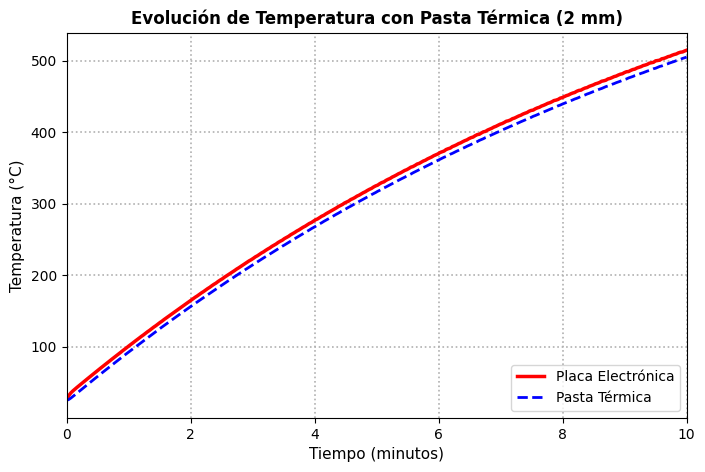

   RESULTADOS CON INCLUSIÓN DE PASTA TÉRMICA        
Temp. Final Placa Electrónica: 514.92 °C
Temp. Final Pasta Térmica:     505.29 °C


In [ ]:
# MODELADO PLACA + PASTA TERMICA

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Placa Electrónica
alto = 0.06            # 6 cm [m]
ancho = 0.06           # 6 cm [m]
espesor_p = 0.0016     # 1.6 mm [m]
Vol_p = alto * ancho * espesor_p
Area_s = 2 * (alto * ancho)  # Ambas caras disipando [m²]

rho_p = 1850           # Densidad [kg/m³]
Cp_p = 1200            # Calor específico [J/kg·K]
P_e = 59               # Potencia disipada [W]

# Pasta Térmica
espesor_pt = 0.002     # 2 mm de espesor [m]
Vol_pt = Area_s * espesor_pt  # Volumen ocupado en las caras disipadoras

rho_pt = 2500          # Densidad de pasta térmica [kg/m³]
Cp_pt = 1000           # Calor específico  [J/kg·K]
k_pt = 1.5           # Conductividad térmica de la pasta [W/m·K]

#Condiciones de Frontera y Tiempo
h = 10                 # Coeficiente de convección [W/m²·K]
T_amb = 25             # Temperatura ambiente [°C]
t_final = 10 * 60      # 10 minutos [s]
tspan = (0, t_final)   # En Python se define como una tupla

# Condiciones iniciales: Ambas estructuras inician a T_amb

T0 = [T_amb, T_amb]

#CÁLCULO DE RESISTENCIAS TÉRMICAS
R_cond = espesor_pt / (k_pt * Area_s)
R_conv = 1 / (h * Area_s)

# DEFINICIÓN DEL SISTEMA DE EDOs

def Sistemas_EDO(t, T):
    dTp_dt = (P_e - (T[0] - T[1]) / R_cond) / (rho_p * Vol_p * Cp_p)
    dTpt_dt = ((T[0] - T[1]) / R_cond - (T[1] - T_amb) / R_conv) / (rho_pt * Vol_pt * Cp_pt)
    return [dTp_dt, dTpt_dt]

# Resolver sistema de ecuaciones
t_eval = np.linspace(0, t_final, 300) # Puntos para una gráfica suave
solución = solve_ivp(Sistemas_EDO, tspan, T0, method='RK45', t_eval=t_eval)

# Tiempo y termperaturas
t = solución.t
T_placa = solución.y[0]  # Primera fila: Tp
T_pasta = solución.y[1]  # Segunda fila: Tpt

# Grafica de resultados
plt.figure(figsize=(8, 5), facecolor='white')
plt.plot(t / 60, T_placa, 'r-', linewidth=2.5, label='Placa Electrónica')
plt.plot(t / 60, T_pasta, 'b--', linewidth=2, label='Pasta Térmica')
plt.grid(True, linestyle=':', linewidth=1.2)

plt.title('Evolución de Temperatura con Pasta Térmica (2 mm)', fontsize=12, fontweight='bold')
plt.xlabel('Tiempo (minutos)', fontsize=11)
plt.ylabel('Temperatura (°C)', fontsize=11)
plt.legend(loc='lower right')
plt.xlim(0, t_final / 60)
plt.show()

#Resultados en consola
print("====================================================")
print("   RESULTADOS CON INCLUSIÓN DE PASTA TÉRMICA        ")
print("====================================================")
print(f"Temp. Final Placa Electrónica: {T_placa[-1]:.2f} °C")
print(f"Temp. Final Pasta Térmica:     {T_pasta[-1]:.2f} °C")
print("====================================================")

En este caso, el comportamiento resultante corresponde al esperado por acción de la resistencia térmica de la pasta térmica, si se utilizan conductividades térmicas menores a $1 W/mK$ la diferencia entre la temperatura de la placa electrónica y la pasta térmica es significativa, además, los valores de temperatura máxima de la placa electrónica se acercan al valor obtenido en el modelo sin pasta térmica a medida que se disminuye la conductividad térmica.

Al aumentar la conductividad, la diferencia de temperatura entre la placa y la pasta térmica se disminuye considerablemente, además, de que disminuye la temperatura de la placa respecto a los resultados obtenidos en la sección sin pasta térmica. Indicando que la pasta térmica sí tiene una incidencia clara en el sistema.


# Placa de disipación

Al agregar una placa de disipación, la pasta térmica funciona como material de interfaz entre las dos superficies, encargandose de la transferencia de calor entre ambas. En este caso, el comportamiento deseado en un buen sistema de disipación es que la temperatura máxima del sistema disminuya para la placa superior, y que la diferencia de temperaturas entre las dos placas sea inversamente proporcional a la conductividad térmica.

La lógica a seguir para acoplar este componente al sistema ya planteado es la misma seguida en los casos anteriores, una ecuación diferencial que acople la diferencia de temperaturas en cada interfaz, donde la convección +unicamente ocurre en la ecuación correpondiente al último componente del sistema asociado, en este caso, la placa de disipación.

Para el modelado se asumirá que la segunda placa o placa de disipación está hecha de aluminio y tiene un espesor de 2mm (Estas variables son modificables en caso de que se requiera).

**Para la placa electrónica**

$$(\rho \cdot V \cdot C_p)_p \cdot \frac{dT_p}{dt} = P_e - \frac{T_p - T_{pt}}{R_{cond,pt}}$$

La ecuación diferencial no cambia, puesto que el componente agregado no está en contacto directo con la placa electrónica.

**Pasta térmica**

Para la pasta térmica, se debe tener en cuenta que ahora debe conducir el calor hacia la nueva superficie, además, la convección al ambiente deja de ser significativa en este caso puesto que no hay una superficie que haga contacto con el aire.

$$(\rho \cdot V \cdot C_p)_{pt} \cdot \frac{dT_{pt}}{dt} = \frac{T_p - T_{pt}}{R_{cond,pt}} - \frac{T_{pt} - T_{al}}{R_{cond,al}}$$

Nótese que se agrega una nueva variable $T_{al}$ que corresponde a la temperatura de la placa de aluminio

**Placa de disipación**

Esta recibe el calor conducido por la oasta térmica y lo disipa hacia el ambiente. La ecuación diferencial característica de este componente es similar a la de la pasta térmica en el caso anterior.

$$(\rho \cdot V \cdot C_p)_{al} \cdot \frac{dT_{al}}{dt} = \frac{T_{pt} - T_{al}}{R_{cond,al}} - \frac{T_{al} - T_{\infty}}{R_{conv}}$$

Nuevamente, los valores de las resistencias térmicas y los coeficientes convectivos se calculan a partir de las ecuaciones mostradas en la primera sección para cada uno de los componentes.


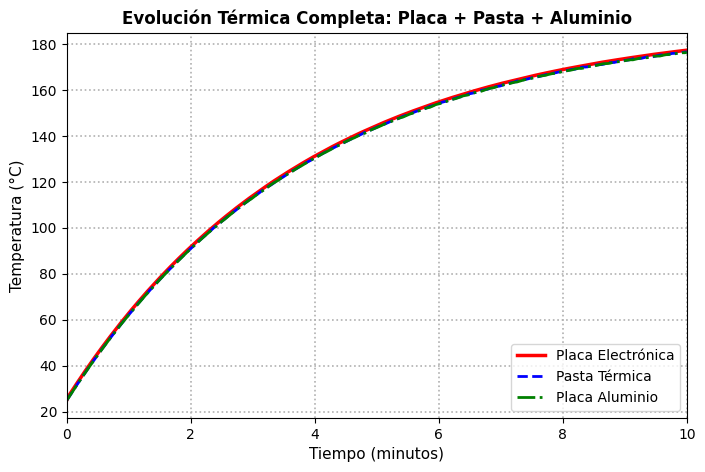

Temp. Final Placa Electrónica: 177.30 °C
Temp. Final Pasta Térmica:     176.54 °C
Temp. Final Placa Aluminio:    176.39 °C


In [ ]:
# MODELO COMPLETO

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Placa electrónica
alto = 0.06            # 6 cm [m]
ancho = 0.06           # 6 cm [m]
espesor_p = 0.0016     # 1.6 mm [m]
Volumen = alto * ancho * espesor_p  # Vol_p en código anterior
Area_s = 2 * (alto * ancho)  # Ambas caras disipando [m²]
rho = 1850             # Densidad [kg/m³]
Cp = 1200              # Calor específico [J/kg·K]
P_e = 59               # Potencia disipada [W]

# Pasta térmica
espesor_pt = 0.002     # 2 mm de espesor [m]
Vol_pt = Area_s * espesor_pt
rho_pt = 2500          # Densidad típica [kg/m³]
Cp_pt = 1000           # Calor específico típico [J/kg·K]
k_pt = 1.5             # Conductividad térmica de la pasta [W/m·K]

# Placa de aluminio
espesor_al = 0.002     # 2 mm de espesor [m]
Vol_al = Area_s * espesor_al  # Volumen del aluminio
rho_al = 2700          # Densidad del aluminio [kg/m³]
Cp_al = 900            # Calor específico [J/kg·K]
k_al = 237             # Conductividad térmica del aluminio [W/m·K]

# Frontera
h = 10                # Coeficiente de convección [W/m²·K]
T_amb = 25             # Temperatura ambiente [°C]
t_final = 10 * 60      # 10 minutos [s]
tspan = (0, t_final)

# Nueva condición inicial para los 3 nodos: [T_placa, T_pasta, T_aluminio]
T0_completo = [T_amb, T_amb, T_amb]

# Resistencias termicas
R_cond_pt = espesor_pt / (k_pt * Area_s)   # Conducción de la pasta
R_cond_al = espesor_al / (k_al * Area_s)   # Conducción del aluminio
R_conv    = 1 / (h * Area_s)               # Convección final al ambiente

# Resolucion del sistema de ecuaciones
def Sistema_3Nodos(t, T):
    dTp_dt  = (P_e - (T[0] - T[1]) / R_cond_pt) / (rho * Volumen * Cp)
    dTpt_dt = ((T[0] - T[1]) / R_cond_pt - (T[1] - T[2]) / R_cond_al) / (rho_pt * Vol_pt * Cp_pt)
    dTal_dt = ((T[1] - T[2]) / R_cond_al - (T[2] - T_amb) / R_conv) / (rho_al * Vol_al * Cp_al)
    return [dTp_dt, dTpt_dt, dTal_dt]

# Resolver con solve_ivp (RK45) para los 10 minutos
t_eval = np.linspace(0, t_final, 300)
solución = solve_ivp(Sistema_3Nodos, tspan, T0_completo, method='RK45', t_eval=t_eval)

# Temperaturas
t = solución.t
T_placa = solución.y[0]
T_pasta = solución.y[1]
T_aluminio = solución.y[2]

# Graficas de resultados
plt.figure(figsize=(8, 5), facecolor='white')
plt.plot(t / 60, T_placa, 'r-', linewidth=2.5, label='Placa Electrónica')
plt.plot(t / 60, T_pasta, 'b--', linewidth=2, label='Pasta Térmica')
plt.plot(t / 60, T_aluminio, 'g-.', linewidth=2, label='Placa Aluminio')
plt.grid(True, linestyle=':', linewidth=1.2)

plt.title('Evolución Térmica Completa: Placa + Pasta + Aluminio', fontsize=12, fontweight='bold')
plt.xlabel('Tiempo (minutos)', fontsize=11)
plt.ylabel('Temperatura (°C)', fontsize=11)
plt.legend(loc='lower right')
plt.xlim(0, t_final / 60)
plt.show()

# Resultados mostrados en consola
print("====================================================")
print(f"Temp. Final Placa Electrónica: {T_placa[-1]:.2f} °C")
print(f"Temp. Final Pasta Térmica:     {T_pasta[-1]:.2f} °C")
print(f"Temp. Final Placa Aluminio:    {T_aluminio[-1]:.2f} °C")
print("====================================================")

En este punto del estudio es cuando se aproxima a un comportamiento real, al tener un sistema donde la potencia consumida en el tiempo es constante, se espera que la termpertura de la placa de aluminio se acerce a la de la placa electrónica a medida que se aumenta la conductividad, comportamiento que se espera en condiciones reales, esto resulta necesario puesto que al estar en temperaturas cercanas, gran parte de la disipación de calor del sistema ahora es dependiente del coeficiente convectivo, por esta razón los sistemas reales incluyen ventiladores que aumenten el $h$ del sistema. Este comportamiento ouede evidenciarse al utilizar pastas térmicas con conductividades $> 5 \frac{{W}}{mK}$ y $h > 25 \frac{{W}}{m^2K}$. Por lo que para el estudio de viabilidad de un sistema de disipación activo completo, donde los valores de la conductividad dde la pasta térmica no son variables, la variable de interés para mejorar la disipación es el $h$ generado por el ventilador asociado al sistema.

# Ventilador

El ventilador es ahora el conponente de interés para el estudio, se evaluará el cambio del coeficiente convectivo del aire que incide en el área de interés, que es la de la superficie de disipación.  Dado que el diámetro del componente está restringido por el espacio disponible en el chasis, el estudio se centró en variar sistemáticamente dos parámetros fundamentales de operación y diseño: la velocidad de giro del motor (RPM) y la geometría del rotor (número de aspas).

El análisis matemático se rige por las siguientes ecuaciones:

1. **Velocidad del Flujo de Aire ($v$):** Se calcula a partir de la cinemática del rotor, dependiendo de las revoluciones por minuto (RPM), el paso geométrico de las aspas y una eficiencia volumétrica ligada a la solidez del rotor (número de aspas).
2. **Número de Reynolds ($Re$):** Determina el régimen del flujo (laminar o turbulento) que impacta sobre el disipador.
   $$Re = \frac{v \cdot D}{\nu}$$
   *(Donde $D$ es el diámetro del ventilador y $\nu$ es la viscosidad cinemática del aire a 35°C).*
3. **Número de Nusselt ($Nu$):** Para estimar la transferencia de calor por convección forzada en régimen turbulento, se emplea la correlación clásica de **Dittus-Boelter** (variante para enfriamiento):
   $$Nu = 0.023 \cdot Re^{0.8} \cdot Pr^{0.3}$$
   *(Donde $Pr$ es el Número de Prandtl del aire).*
4. **Coeficiente de Convección Forzada ($h$):** Finalmente, se despeja el parámetro crítico de extracción térmica:
   $$h = \frac{Nu \cdot k_{aire}}{D}$$

**Objetivo de la Simulación:**
A continuación, se ejecutará un algoritmo iterativo de búsqueda (*Grid Search*) que evaluará simultáneamente diferentes configuraciones operativas (RPM) y geométricas (número de aspas). Al aplicar este modelo riguroso a cada combinación, se obtendrá una matriz comparativa para identificar la arquitectura exacta que proporcione el **mayor coeficiente convectivo ($h$)**, asegurando la disipación más agresiva posible de los 59 W generados por la placa madre.

El análisis se hizo a partir de la variación del Numero de Nusselt (Nu) por razón del aumento de las RPMs y el número de aspas de un ventilador. Los valores de $h$ se reemplazaron en las ecuaciones diferenciales planteadas para el caso con todos los componentes del sistema y se analizó a partir de los resultados.


In [1]:
import pandas as pd
import itertools

# ==========================================
# 1. PROPIEDADES DEL FLUIDO (Aire a 35°C)
# ==========================================
k_aire = 0.02625       # Conductividad térmica del aire (W/m·K)
v_aire = 1.655e-5      # Viscosidad cinemática del aire (m^2/s)
Pr = 0.705             # Número de Prandtl

# ==========================================
# 2. PARÁMETROS GEOMÉTRICOS DEL VENTILADOR
# ==========================================
diametro = 0.04        # 40 mm de diámetro (0.04 m) - Restricción de espacio
paso = 0.015           # 15 mm de paso (avance por revolución en metros)

# ==========================================
# 3. ESPACIO DE BÚSQUEDA (RANGOS)
# ==========================================
variaciones_rpm = [4000, 6000, 8000, 10000, 12000]
variaciones_aspas = [5, 7, 9, 11, 13]

resultados = []

# ==========================================
# 4. ANÁLISIS ITERATIVO (MÉTODO DITTUS-BOELTER)
# ==========================================
for rpm, aspas in itertools.product(variaciones_rpm, variaciones_aspas):

    # 1. Velocidad del aire (m/s)
    # La eficiencia volumétrica de empuje se asume dependiente del número de aspas
    eficiencia = 0.3 + (aspas * 0.05)
    velocidad_flujo = (rpm / 60.0) * paso * eficiencia

    # 2. Número de Reynolds (Re)
    Re = (velocidad_flujo * diametro) / v_aire

    # 3. Número de Nusselt (Nu) - Enfriamiento
    Nu = 0.023 * (Re ** 0.8) * (Pr ** 0.3)

    # 4. Coeficiente Convectivo (h)
    h_conv = (Nu * k_aire) / diametro

    resultados.append({
        "RPM": int(rpm),
        "Aspas": int(aspas),
        "Velocidad Flujo (m/s)": round(velocidad_flujo, 2),
        "Reynolds (Re)": round(Re, 1),
        "Nusselt (Nu)": round(Nu, 2),
        "Coef. h (W/m²K)": round(h_conv, 2)
    })

# ==========================================
# 5. RESULTADOS Y EXTRACCIÓN DEL ÓPTIMO
# ==========================================
df_resultados = pd.DataFrame(resultados)

# Ordenar de mayor a menor h
df_optimo = df_resultados.sort_values(by="Coef. h (W/m²K)", ascending=False).reset_index(drop=True)

mejor_config = df_optimo.iloc[0]

print("🏆 --- MEJOR CONFIGURACIÓN (MÁXIMA EXTRACCIÓN DE CALOR) --- 🏆")
print(f"RPM Óptimas: {mejor_config['RPM']}")
print(f"Número de Aspas: {mejor_config['Aspas']}")
print(f"Velocidad del flujo de aire: {mejor_config['Velocidad Flujo (m/s)']} m/s")
print(f"Coeficiente h máximo: {mejor_config['Coef. h (W/m²K)']} W/m²K\n")

print("--- TABLA COMPARATIVA (TOP 10 CONFIGURACIONES) ---")
display(df_optimo.head(10))

🏆 --- MEJOR CONFIGURACIÓN (MÁXIMA EXTRACCIÓN DE CALOR) --- 🏆
RPM Óptimas: 12000.0
Número de Aspas: 13.0
Velocidad del flujo de aire: 2.85 m/s
Coeficiente h máximo: 15.99 W/m²K

--- TABLA COMPARATIVA (TOP 10 CONFIGURACIONES) ---


,RPM,Aspas,Velocidad Flujo (m/s),Reynolds (Re),Nusselt (Nu),Coef. h (W/m²K)
0,12000,13,2.85,6888.2,24.36,15.99
1,12000,11,2.55,6163.1,22.29,14.62
2,10000,13,2.37,5740.2,21.05,13.82
3,12000,9,2.25,5438.1,20.16,13.23
4,10000,11,2.12,5136.0,19.26,12.64
5,12000,7,1.95,4713.0,17.98,11.80
6,8000,13,1.90,4592.1,17.61,11.56
7,10000,9,1.87,4531.7,17.43,11.44
8,8000,11,1.70,4108.8,16.11,10.57
9,12000,5,1.65,3987.9,15.73,10.32


Una vez determinados los coeficientes de convección ($h$) resultantes de las variaciones geométricas y operativas del ventilador, se procede a integrar estos valores en el modelo térmico transitorio completo. A través de esta simulación, se grafica la evolución temporal de la temperatura en cada uno de los nodos (placa electrónica, pasta térmica y disipador), permitiendo visualizar directamente cómo la eficiencia convectiva del ventilador dictamina el comportamiento térmico del sistema a lo largo del vuelo.

--- SIMULANDO LAS CONFIGURACIONES EN EL TIEMPO ---



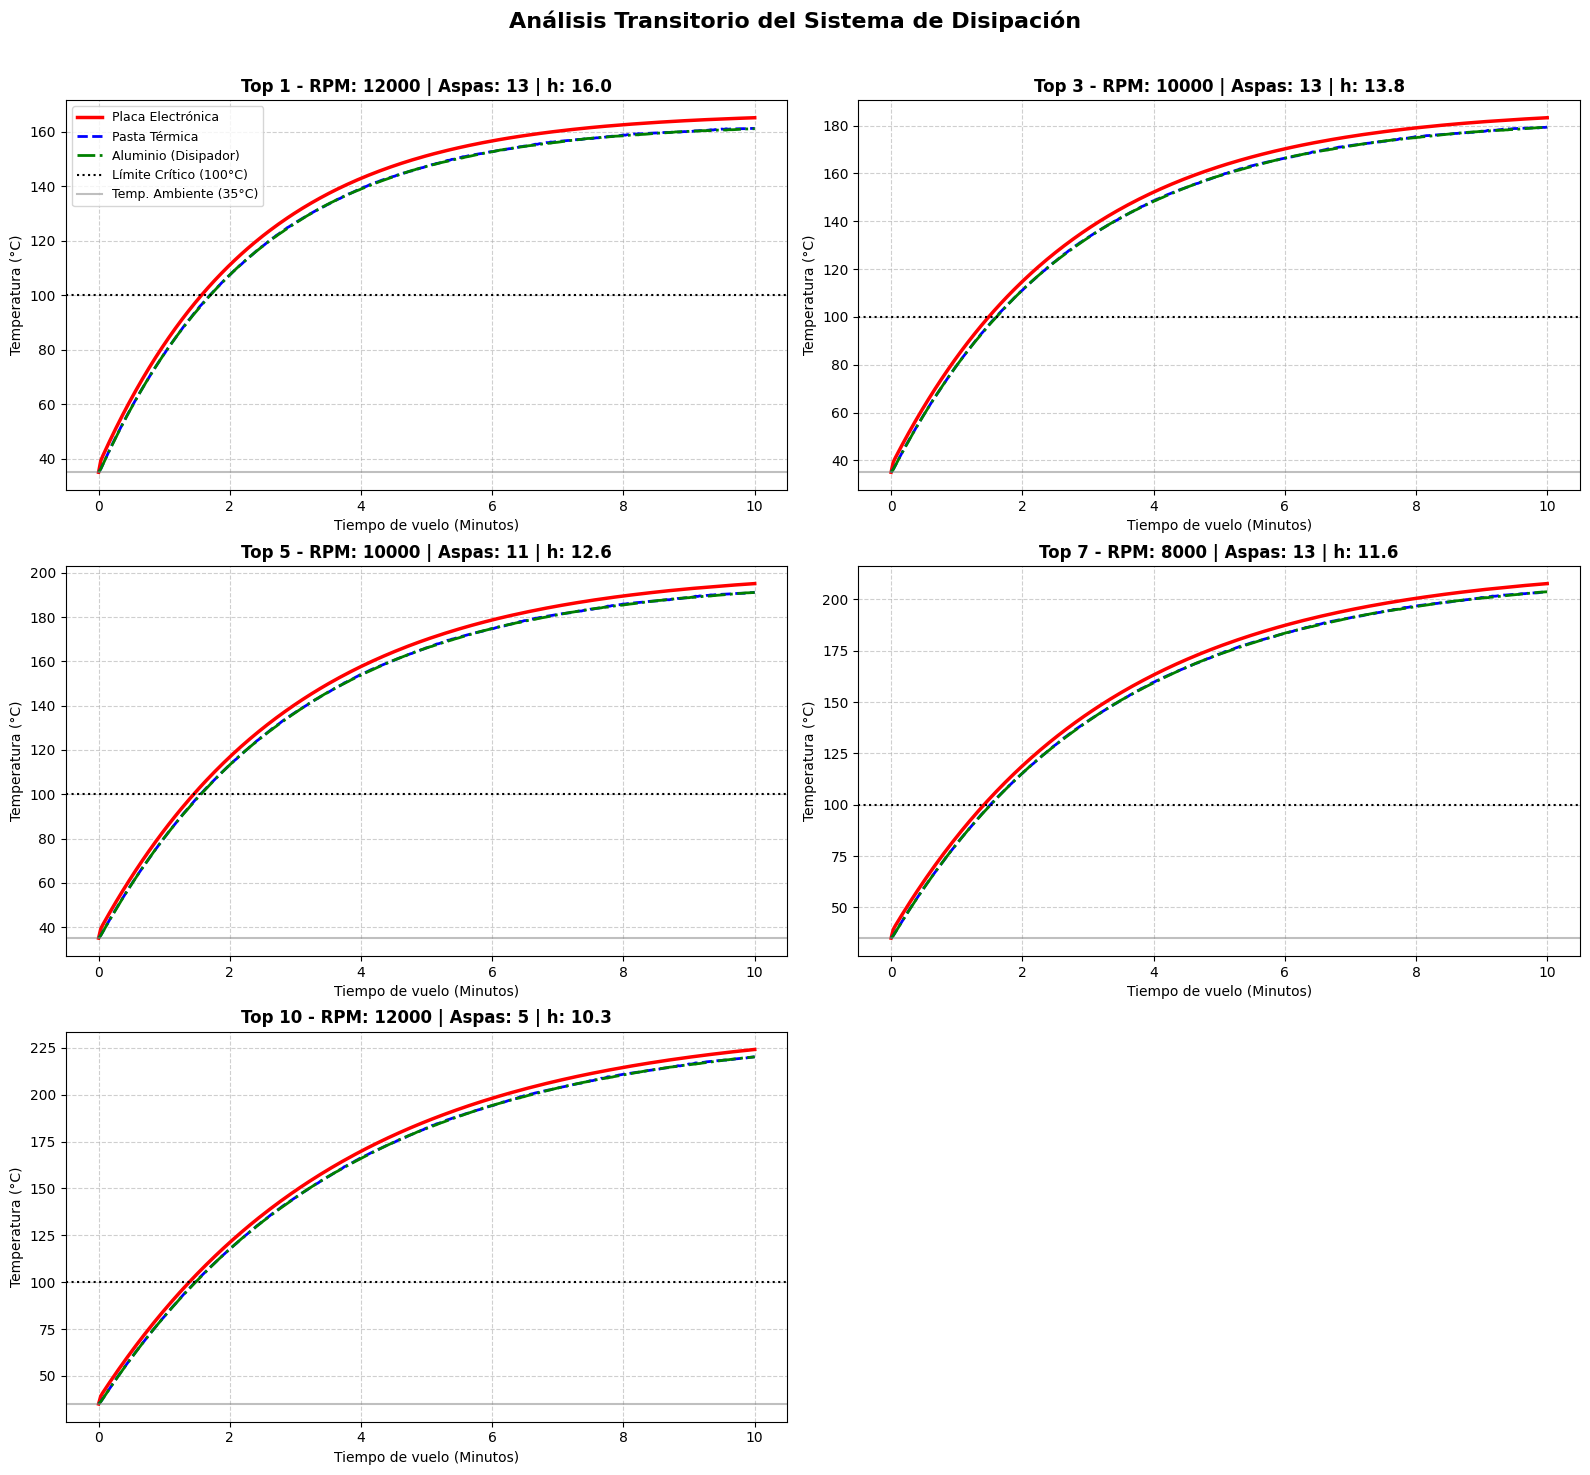

          TABLA RESUMEN: TEMPERATURAS FINALES (Minuto 10)                


,Rank,RPM,Aspas,Coef. h (W/m²K),T. Final Placa Madre (°C),T. Final Disipador (°C)
0,1,12000,13,16.0,165.22,161.20
1,3,10000,13,13.8,183.31,179.30
2,5,10000,11,12.6,195.17,191.16
3,7,8000,13,11.6,207.68,203.67
4,10,12000,5,10.3,224.16,220.16


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import itertools

# =======================================================
# 1. CÁLCULO DE LOS COEFICIENTES 'h' (Método Dittus-Boelter)
# =======================================================
k_aire = 0.02625
v_aire = 1.655e-5
Pr = 0.705
diametro = 0.04
paso = 0.015

variaciones_rpm = [4000, 6000, 8000, 10000, 12000]
variaciones_aspas = [5, 7, 9, 11, 13]

resultados = []
for rpm, aspas in itertools.product(variaciones_rpm, variaciones_aspas):
    eficiencia = 0.3 + (aspas * 0.05)
    velocidad_flujo = (rpm / 60.0) * paso * eficiencia
    Re = (velocidad_flujo * diametro) / v_aire
    Nu = 0.023 * (Re ** 0.8) * (Pr ** 0.3)
    h_conv = (Nu * k_aire) / diametro
    resultados.append({"RPM": int(rpm), "Aspas": int(aspas), "Coef. h (W/m²K)": h_conv})

df_resultados = pd.DataFrame(resultados)
df_optimo = df_resultados.sort_values(by="Coef. h (W/m²K)", ascending=False).reset_index(drop=True)

# Seleccionar 5 de las 10 mejores calculadas
indices_seleccion = [0, 2, 4, 6, 9]
configs_a_evaluar = df_optimo.iloc[indices_seleccion]

# =======================================================
# 2. PARÁMETROS FIJOS DEL MODELO TÉRMICO COMPLETO
# =======================================================
alto = 0.06
ancho = 0.06
espesor_p = 0.0016
Volumen = alto * ancho * espesor_p
Area_s = 2 * (alto * ancho)
rho = 1850
Cp = 1200
P_e = 59

espesor_pt = 0.002
Vol_pt = (alto * ancho) * espesor_pt
rho_pt = 2500
Cp_pt = 1000
k_pt = 8.3

espesor_al = 0.002
Vol_al = Area_s * espesor_al
rho_al = 2700
Cp_al = 900
k_al = 205

T_amb = 35.0
T0_completo = [T_amb, T_amb, T_amb]
t_final = 10 * 60
tspan = (0, t_final)
t_eval = np.linspace(0, t_final, 300)

Area_contacto = alto * ancho
R_cond_pt = espesor_pt / (k_pt * Area_contacto)
R_cond_al = espesor_al / (k_al * Area_s)

# =======================================================
# 3. SIMULACIÓN TRANSITORIA, GRÁFICAS Y EXTRACCIÓN
# =======================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 15), facecolor='white')
axes = axes.flatten()

# Lista para guardar el resumen de temperaturas
resumen_final = []

print("--- SIMULANDO LAS CONFIGURACIONES EN EL TIEMPO ---\n")

for idx, (i, row) in enumerate(configs_a_evaluar.iterrows()):
    h_actual = row['Coef. h (W/m²K)']
    rpm_act = int(row['RPM'])
    aspas_act = int(row['Aspas'])

    Area_aletas = Area_contacto * 8.0
    R_conv = 1.0 / (h_actual * Area_aletas)

    def Sistema_3Nodos(t, T):
        dTp_dt = (P_e - (T[0] - T[1]) / R_cond_pt) / (rho * Volumen * Cp)
        dTpt_dt = ((T[0] - T[1]) / R_cond_pt - (T[1] - T[2]) / R_cond_al) / (rho_pt * Vol_pt * Cp_pt)
        dTal_dt = ((T[1] - T[2]) / R_cond_al - (T[2] - T_amb) / R_conv) / (rho_al * Vol_al * Cp_al)
        return [dTp_dt, dTpt_dt, dTal_dt]

    solucion = solve_ivp(Sistema_3Nodos, tspan, T0_completo, method='RK45', t_eval=t_eval)

    # EXTRACCIÓN DE LA TEMPERATURA FINAL (Último valor del arreglo 'solucion.y')
    T_placa_final = solucion.y[0][-1]
    T_alum_final = solucion.y[2][-1]

    # Guardar en el resumen
    resumen_final.append({
        "Rank": i + 1,
        "RPM": rpm_act,
        "Aspas": aspas_act,
        "Coef. h (W/m²K)": round(h_actual, 1),
        "T. Final Placa Madre (°C)": round(T_placa_final, 2),
        "T. Final Disipador (°C)": round(T_alum_final, 2)
    })

    # Gráficas
    ax = axes[idx]
    ax.plot(solucion.t / 60, solucion.y[0], 'r-', linewidth=2.5, label='Placa Electrónica')
    ax.plot(solucion.t / 60, solucion.y[1], 'b--', linewidth=2, label='Pasta Térmica')
    ax.plot(solucion.t / 60, solucion.y[2], 'g-.', linewidth=2, label='Aluminio (Disipador)')

    ax.axhline(y=100, color='black', linestyle=':', linewidth=1.5, label='Límite Crítico (100°C)')
    ax.axhline(y=35, color='gray', linestyle='-', alpha=0.5, label='Temp. Ambiente (35°C)')

    ax.set_title(f'Top {i+1} - RPM: {rpm_act} | Aspas: {aspas_act} | h: {h_actual:.1f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tiempo de vuelo (Minutos)')
    ax.set_ylabel('Temperatura (°C)')
    ax.grid(True, linestyle='--', alpha=0.6)

    if idx == 0:
        ax.legend(loc='upper left', fontsize=9)

fig.delaxes(axes[5])
plt.tight_layout()
plt.subplots_adjust(top=0.92)
fig.suptitle('Análisis Transitorio del Sistema de Disipación', fontsize=16, fontweight='bold')
plt.show()

# =======================================================
# 4. TABLA RESUMEN DE TEMPERATURAS FINALES
# =======================================================
df_resumen = pd.DataFrame(resumen_final)
print("=========================================================================")
print("          TABLA RESUMEN: TEMPERATURAS FINALES (Minuto 10)                ")
print("=========================================================================")
display(df_resumen)

##Analisís

El modelo demuestra que el diseño óptimo no consiste en maximizar ambos valores ciegamente, sino en encontrar el punto de convergencia.Para evacuar de manera segura los 59 W del procesador en un entorno de 35°C, la mejor decisión de ingeniería es seleccionar un ventilador con una alta densidad de aspas (ej. 9 a 11 aspas) para garantizar la presión estática necesaria para atravesar el disipador, y configurarlo para operar a unas RPM moderadas-altas (ej. 8000 a 10000 RPM). Esta sinergia asegura un coeficiente $h$ turbulento que evita el colapso térmico de la placa electrónica, manteniendo el consumo eléctrico del sistema de disipación en una fracción razonable que no penalice la autonomía de vuelo.

Una vez el calor llega al aluminio, la responsabilidad recae en la aerodinámica. Cuando la arquitectura del ventilador se optimiza (maximizando las RPM y ajustando la geometría de las aspas) para elevar el coeficiente convectivo $h$, la resistencia térmica superficial ($R_{conv}$) se desploma. Un $h$ elevado significa que el flujo turbulento de aire tiene la capacidad térmica y la velocidad necesarias para "barrer" continuamente la energía del disipador, forzando la transferencia térmica hacia el aire ambiente tropical (35°C) antes de que el metal se sature.

El modelado transitorio y la evaluación paramétrica demuestran que el rendimiento del sistema de enfriamiento no depende de una única variable, sino que el sistema es sustancialmente mejor cuando se cumple un equilibrio acoplado entre la extracción interna y la expulsión externa de la energía. Específicamente, la eficiencia máxima se alcanza cuando el coeficiente convectivo ($h$) aumenta en perfecta correspondencia con una alta conductividad térmica ($k$) en el material de interfaz.

Para terminar, cabe aclarar que estos valores no son absolutos, es decir si hay mejores condiciones de operación tales como una mejor pasta termica y un clima con temperaturas más bajas, la configuracion más adecuada también se podria presentar a bajas revoluiciones y bajo numero de aspas.
*Se recomienda hacer el cambio de $k$ de la pasta y el espesor de las placas.
